In [6]:
import pandas as pd
import numpy as np
# for visul
import matplotlib.pyplot as plt
import seaborn as sns
# for model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/linear Regression model/xy dataset.csv')
df.head()

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984


In [9]:
df.tail()

,x,y
695,58.0,58.595006
696,93.0,94.625094
697,82.0,88.603770
698,66.0,63.648685
699,97.0,94.975266


In [10]:
df.shape

(700, 2)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       700 non-null    float64
 1   y       699 non-null    float64
dtypes: float64(2)
memory usage: 11.1 KB


In [12]:
df.describe()

,x,y
count,700.000000,699.000000
mean,54.985939,49.939869
std,134.681703,29.109217
min,0.000000,-3.839981
25%,25.000000,24.929968
50%,49.000000,48.973020
75%,75.000000,74.929911
max,3530.157369,108.871618


In [13]:
df.isnull().sum()

,0
x,0
y,1


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.corr()

,x,y
x,1.00000,0.99534
y,0.99534,1.00000


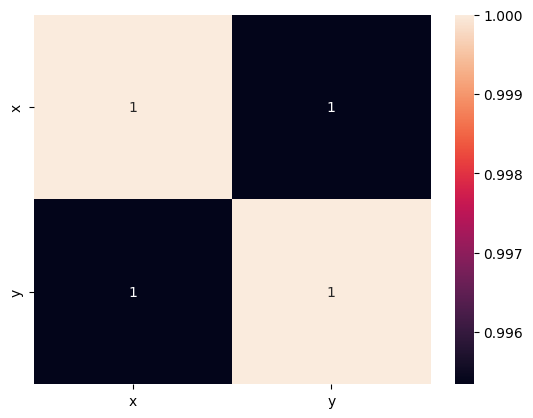

In [16]:
sns.heatmap(df.corr(), annot=True)
plt.show()

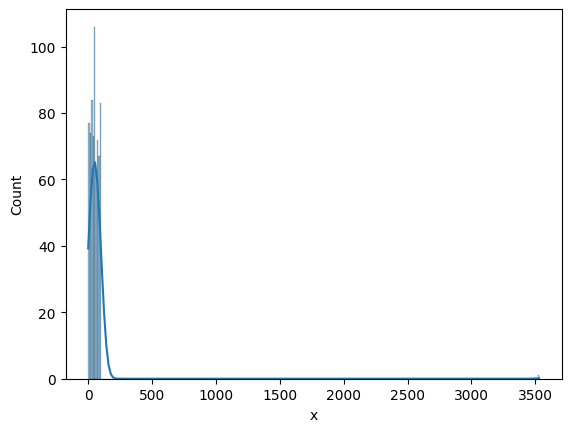

In [18]:
sns.histplot(df['x'], kde=True)
plt.show()

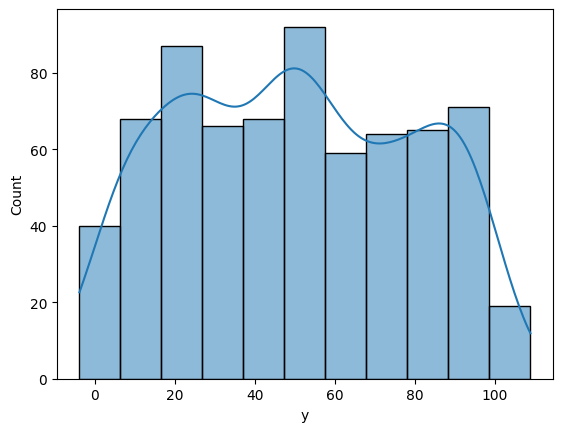

In [21]:
sns.histplot(df['y'], kde=True)
plt.show()

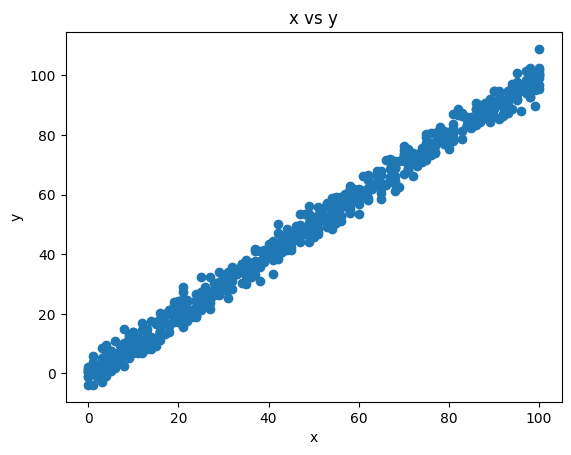

In [24]:
plt.scatter(df['x'], df['y'])
plt.xlabel("x")
plt.ylabel("y")
plt.title("x vs y")
plt.show()

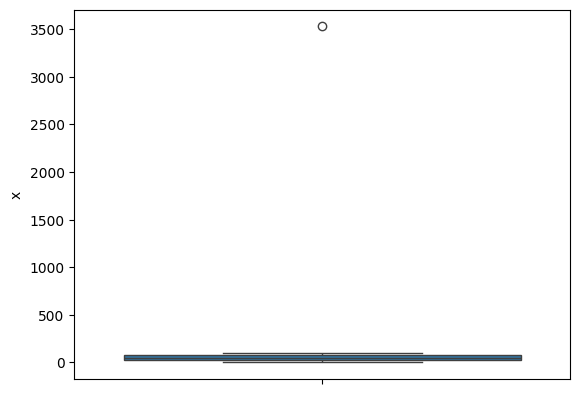

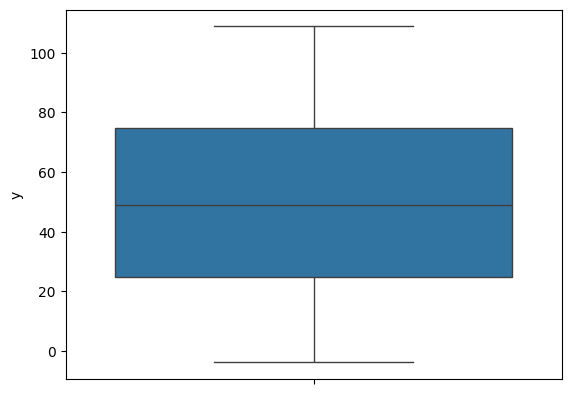

In [27]:
sns.boxplot(df['x'])
plt.show()

sns.boxplot(df['y'])
plt.show()

In [42]:
X = df[['x']]
Y = df['y']

In [43]:
print(type(X))
print(X.shape)

<class 'pandas.core.frame.DataFrame'>
(699, 1)


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

In [45]:
X_train = X_train.values.reshape(-1, 1)
X_test = X_test.values.reshape(-1, 1)

In [46]:
model = LinearRegression()

In [47]:
model.fit(X_train, y_train)

LinearRegression()

In [48]:
y_pred = model.predict(X_test)

print(y_pred)

[ 1.00025030e+02  9.70213794e+01  1.19179548e+01  8.60079950e+01
  9.10140788e+01  1.00025030e+02  6.49824431e+01  2.49337727e+01
  3.39447235e+01  2.19301224e+01  6.09775760e+01  2.19301224e+01
  5.09654084e+01  4.90943749e+00  1.90578721e+00  3.19422900e+01
  2.49337727e+01 -9.66463086e-02  3.49459403e+01  4.29556744e+01
  9.90238129e+01  1.69240386e+01  2.39325559e+01  9.04570451e-01
  4.90943749e+00  7.39933939e+01  2.89386397e+01  1.39203883e+01
  3.49459403e+01  7.79982610e+01  6.79860934e+01  1.39203883e+01
  7.89994777e+01  5.59714922e+01  5.19666252e+01  7.59958274e+01
  4.29556744e+01  2.29313392e+01  9.10140788e+01  2.69362062e+01
  1.90578721e+00  4.90943749e+00  4.99641917e+01  4.39568911e+01
  4.69605414e+01  2.90700397e+00  5.79739258e+01  9.80225962e+01
  6.91187101e+00  6.91187101e+00  3.69483738e+01  5.29678420e+01
  3.39447235e+01  1.59228218e+01  5.09654084e+01  8.10019112e+01
  5.19666252e+01  4.69605414e+01  5.99763593e+01  4.19544576e+01
  2.49337727e+01  7.89994

Evaluate Model

In [49]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9910998765243975


In [50]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 2.2020818674091127


In [51]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 7.752986666319193


Premium=(Slope×Age)+Intercept

In [52]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 1.0012167598754458
Intercept: -0.09664630862199175


In [56]:
new_x = [[30]]

predicted_y = model.predict(new_x)

print("Predicted y:", predicted_y[0])

Predicted y: 29.939856487641382


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


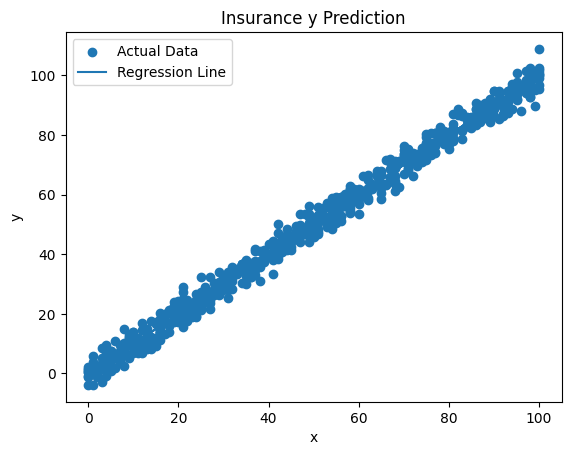

In [57]:
import matplotlib.pyplot as plt

plt.scatter(X, Y, label="Actual Data")

plt.plot(X, model.predict(X), label="Regression Line")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Insurance y Prediction")

plt.legend()
plt.show()

## Model Summary: Quick Insights

Our Linear Regression model effectively explains the relationship between `x` and `y`:

*   **Excellent Fit (R2 Score: 0.9911):** The model captures over 99% of the variation in `y` using `x`, indicating a very strong relationship.
*   **Low Average Error (MAE: 2.2021):** On average, predictions are very close to the actual values.
*   **Positive Relationship (Slope: 1.0012):** For every unit increase in `x`, `y` increases by approximately 1 unit.
*   **Baseline `y` (Intercept: -0.0966):** When `x` is zero, `y` is approximately -0.1.